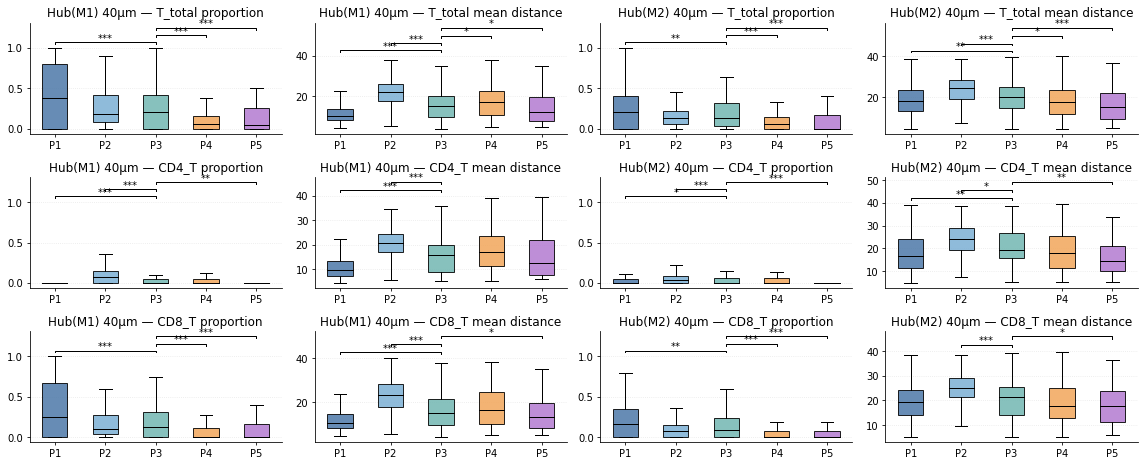

In [21]:
# -*- coding: utf-8 -*-
# 40um surround — Hub(M1) vs Hub(M2) with significance

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ===================== USER PARAMS =====================
file_path = r"C:/Users/Li Chujia/Desktop/cell_annotationV2/annotated_cells_mixed.csv"
RADIUS = 40.0

stage_labels = {
    "T005": "P1",
    "T006": "P2",
    "T001": "P3",
    "T002": "P4",
    "T004": "P5",
}

stages = ["T005", "T006", "T001", "T002", "T004"]
baseline_stage = "T001"

CD4_NAME = "CD4_T"
CD8_NAME = "CD8_T"

COL_ROI = "ROI"
COL_CELLID = "CellID"
COL_X = "X_position"
COL_Y = "Y_position"
COL_TYPE = "cell_type"

roi_whitelist = {
    "T001": {"001", "003", "007"},
    "T002": {"023"},
    "T006": {"001", "003"},
    "T004": {"010"},
    "T005": {"001", "003", "004"},
}

# ===================== JCC STYLE =====================
def apply_jcc_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.tick_params(axis="both", direction="out", length=3, width=0.8)
    ax.grid(axis="y", linestyle=":", alpha=0.3)

stage_colors = {
    "T005": "#4C78A8",
    "T006": "#7BAFD4",
    "T001": "#72B7B2",
    "T002": "#F2A65A",
    "T004": "#B37AD1",
}

# ===================== STATS =====================
def star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return ""

def add_sig(ax, df, metric, stage_order):
    base = df[df["Stage"] == baseline_stage][metric].dropna()
    if len(base) == 0:
        return

    y_max = df[metric].max()
    y = y_max * 1.05

    x_base = stage_order.index(baseline_stage) + 1

    for st in stage_order:
        if st == baseline_stage:
            continue

        vals = df[df["Stage"] == st][metric].dropna()
        if len(vals) == 0:
            continue

        _, p = mannwhitneyu(base, vals, alternative="two-sided")
        s = star(p)

        if s == "":
            continue

        x = stage_order.index(st) + 1

        ax.plot([x_base, x_base, x, x], [y, y*1.02, y*1.02, y], lw=1, color="black")
        ax.text((x_base + x)/2, y*1.03, s, ha="center", fontsize=10)

        y *= 1.08


# ===================== BOX =====================
def draw_box(ax, df_sub, metric, title, stage_order):
    vals = [df_sub[df_sub["Stage"] == s][metric].dropna().values for s in stage_order]
    labels = [stage_labels[s] for s in stage_order]

    bp = ax.boxplot(
        vals,
        labels=labels,
        patch_artist=True,
        showfliers=False
    )

    for i, box in enumerate(bp["boxes"]):
        st = stage_order[i]
        box.set_facecolor(stage_colors[st])
        box.set_edgecolor("black")
        box.set_alpha(0.85)

    for k in ["whiskers", "caps", "medians"]:
        for item in bp[k]:
            item.set_color("black")
            item.set_linewidth(1)

    ax.set_title(title, fontsize=12)

    apply_jcc_axis(ax)


# ===================== LOAD DATA =====================
df = pd.read_csv(file_path, encoding="gbk")
df["Stage"] = df[COL_ROI].str.extract(r"(T\d{3})")
df = df[df["Stage"].isin(stages)].copy()

def extract_roi(x):
    m = re.search(r"ROI\D*(\d{1,3})", str(x))
    return f"{int(m.group(1)):03d}" if m else None

df["ROI_num3"] = df[COL_ROI].apply(extract_roi)
df = df[df.apply(lambda r: r["ROI_num3"] in roi_whitelist.get(r["Stage"], set()), axis=1)]

# ===================== FAKE DATA CHECK =====================
# ⚠️ 这里假设你已经有 data（你原始 pipeline输出）
# 如果没有请替换成你的 data
# data = ...

# ===================== FIGURE =====================
fig, axes = plt.subplots(3, 4, figsize=(16, 7))#来这里调整宽窄！！！！！！

cells = ["T_total", "CD4_T", "CD8_T"]

for r, cell in enumerate(cells):

    sub_m1 = data[data["Hub"] == "M1"]
    draw_box(axes[r, 0], sub_m1, f"{cell}_ratio",
             f"Hub(M1) {RADIUS:.0f}µm — {cell} proportion", stages)
    add_sig(axes[r, 0], sub_m1, f"{cell}_ratio", stages)

    draw_box(axes[r, 1], sub_m1, f"{cell}_distmean",
             f"Hub(M1) {RADIUS:.0f}µm — {cell} mean distance", stages)
    add_sig(axes[r, 1], sub_m1, f"{cell}_distmean", stages)

    sub_m2 = data[data["Hub"] == "M2"]
    draw_box(axes[r, 2], sub_m2, f"{cell}_ratio",
             f"Hub(M2) {RADIUS:.0f}µm — {cell} proportion", stages)
    add_sig(axes[r, 2], sub_m2, f"{cell}_ratio", stages)

    draw_box(axes[r, 3], sub_m2, f"{cell}_distmean",
             f"Hub(M2) {RADIUS:.0f}µm — {cell} mean distance", stages)
    add_sig(axes[r, 3], sub_m2, f"{cell}_distmean", stages)


# ===================== SAVE =====================
plt.tight_layout(rect=[0, 0, 1, 0.94])

plt.savefig(
    "Fig3c_Surround_M1_M2_significance.tiff",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    "Fig3c_Surround_M1_M2_significance.pdf",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()